In [1]:
import os
from glob import glob
import numpy as np
from roman_cuts import RomanCuts
from roman_cuts.utils import WCS_ATTRS, extract_average_WCS, extract_all_WCS
from astropy.io import fits
import pandas as pd
import matplotlib.pyplot as plt
import asdf

import logging
from roman_cuts import log as roman_log

In [2]:
roman_log.setLevel(logging.INFO)
roman_log

<Logger roman_cuts (INFO)>

In [3]:
 import sys
 def sizeof_fmt(num, suffix='B'):
     for unit in ['','Ki','Mi','Gi','Ti','Pi','Ei','Zi']:
         if abs(num) < 1024.0:
             return "%3.1f%s%s" % (num, unit, suffix)
         num /= 1024.0
     return "%.1f%s%s" % (num, 'Yi', suffix)

In [4]:
PATH = "/Users/jimartin/Work/ROMAN/TRExS/simulations/dryrun_01"
SSDPATH = "/Volumes/JorgeMarpa-2T/trexs/dryrun_01"

In [5]:
FILTER = "F146"
SCA = 2
FIELD = 3

In [6]:
ff = ["rimtimsim_WFI_lvl02_F146_SCA02_field03_rampfitted_r1920c1920_256x256_sim.asdf"]

In [7]:
%%time
# no mem map version
rcube = RomanCuts(field=FIELD, sca=SCA, filter="F146", file_list=ff, file_format="asdf")
# rcube

CPU times: user 5.07 s, sys: 64.6 ms, total: 5.14 s
Wall time: 5.16 s


In [10]:
%%timeit
# no mem map version
rcube = RomanCuts(field=FIELD, sca=SCA, filter="F146", file_list=ff, file_format="asdf")
# rcube

18.6 s ± 60.6 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)


In [21]:
%%time
# keeping asdf object open
rcube = RomanCuts(field=FIELD, sca=SCA, filter="F146", file_list=ff, file_format="asdf")
# rcube

CPU times: user 4.74 s, sys: 181 ms, total: 4.93 s
Wall time: 4.93 s


In [15]:
%%timeit
# keeping asdf object open
rcube = RomanCuts(field=FIELD, sca=SCA, filter="F146", file_list=ff, file_format="asdf")
# rcube

2.9 s ± 50.9 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)


In [11]:
datamodel = asdf.open(ff[0], lazy_tree=True, lazy_load=True, memmap=True)

In [20]:
sizeof_fmt(sys.getsizeof(datamodel))

'48.0B'

In [12]:
datamodel.info()

root (AsdfObject)
├─asdf_library (Software)
│ ├─author (str): The ASDF Developers
│ ├─homepage (str): http://github.com/asdf-format/asdf
│ ├─name (str): asdf
│ └─version (str): 4.1.0
├─history (AsdfDictNode)
│ └─extensions (AsdfListNode)
│   ├─0 (ExtensionMetadata) ...
│   └─1 (ExtensionMetadata) ...
└─roman (AsdfDictNode)
  ├─data (AsdfDictNode)
  │ ├─column (int): 1792
  │ ├─exposureno (NDArrayType) ...
  │ ├─flux (NDArrayType) ...
  │ ├─flux_err (NDArrayType) ...
  │ ├─quality (NDArrayType) ...
  │ ├─row (int): 1792
  │ └─time (NDArrayType) ...
  ├─meta (AsdfDictNode)
  │ ├─CREATOR (str): TRExS-roman-cuts
  │ └─17 not shown
  └─wcs (AsdfListNode) ...
Some nodes not shown.


In [13]:
flux_mmap = datamodel.tree["roman"]["data"]["flux"]

In [19]:
sizeof_fmt(sys.getsizeof(flux_mmap))

'48.0B'

In [13]:
rcube.metadata

{'CREATOR': 'TRExS-roman-cuts',
 'DEC_CEN': -29.206044018508674,
 'DETECTOR': 'SCA02',
 'DITHERED': False,
 'EQUINOX': 2000.0,
 'EXPOSURE': 54.72,
 'FIELD': 3,
 'FILTER': 'F146',
 'IMGSIZE': [256, 256],
 'MISSION': 'Roman-Sim',
 'NTIMES': 6595,
 'RADESYS': 'FK5',
 'RA_CEN': 268.4914173252764,
 'READMODE': 'rampfitted',
 'SOFTWARE': 'rimtimsim_v2.0',
 'TELESCOP': 'Roman',
 'TEND': 2461520.4886663454,
 'TSTART': 2461450.4999847086}

In [8]:
rcube.quality, rcube.time

(array([0, 0, 0, ..., 0, 0, 0]),
 array([2461450.50030138, 2461450.51041927, 2461450.52046775, ...,
        2461520.46819011, 2461520.47823334, 2461520.48834968]))

In [9]:
rcube.nt, rcube.row_min_data, rcube.column_min_data, rcube.row_max_data, rcube.column_max_data

(6595, 1792, 1792, 2048, 2048)

In [10]:
%%time
ra, dec = 268.490400, -29.209570
rcube.make_cutout(radec=(ra, dec), size=(17, 17), dithered=False)

CPU times: user 5.09 s, sys: 904 ms, total: 6 s
Wall time: 6.05 s


In [22]:
%%time
ra, dec = 268.490404, -29.209571
rcube.make_cutout(radec=(ra, dec), size=(17, 17), dithered=False)

CPU times: user 5.15 s, sys: 971 ms, total: 6.12 s
Wall time: 6.21 s


In [18]:
rcube.column, rcube.row

(array([1793, 1794, 1795, 1796, 1797, 1798, 1799, 1800, 1801, 1802, 1803,
        1804, 1805, 1806, 1807]),
 array([1944, 1945, 1946, 1947, 1948, 1949, 1950, 1951, 1952, 1953, 1954,
        1955, 1956, 1957, 1958]))

In [19]:
rcube.flux.shape

(6595, 15, 15)

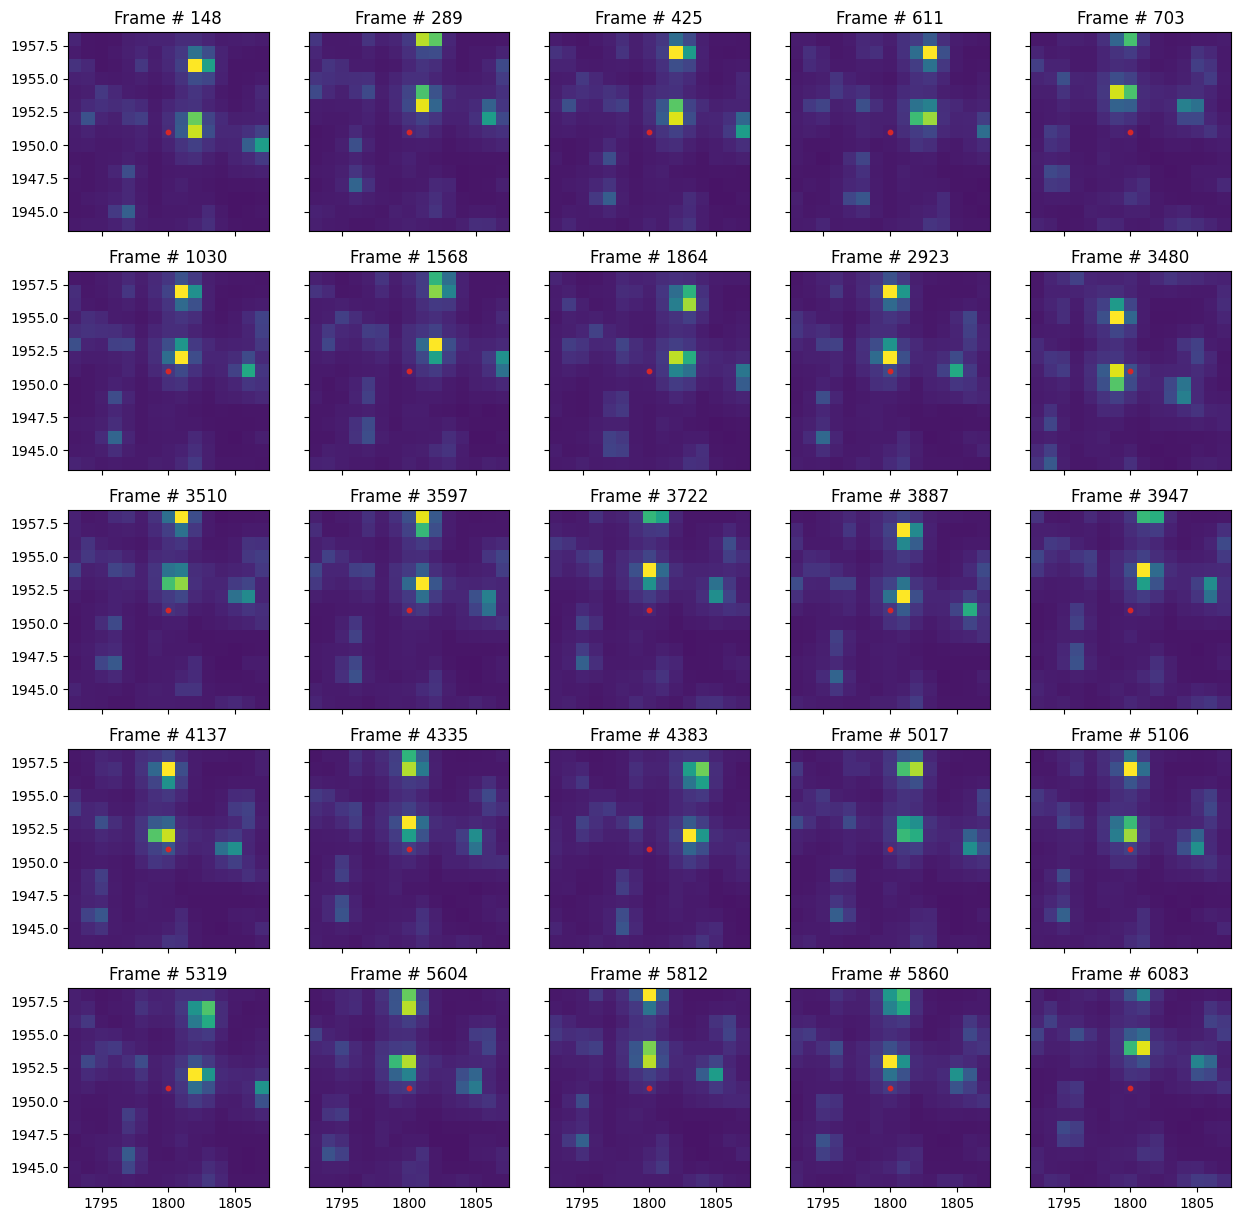

In [20]:
Ts = np.sort(np.random.choice(np.arange(rcube.nt), size=5*5, replace=False))

fig, ax = plt.subplots(5,5,figsize=(15,15),sharex=True, sharey=True)
for t, axis in zip(Ts, ax.ravel()):
    axis.pcolormesh(rcube.column, rcube.row, rcube.flux[t], vmin=-10, vmax=500, cmap="viridis")
    axis.scatter(rcube.target_pixel[1],rcube.target_pixel[0], c="tab:red", s=10)
    axis.set_title(f"Frame # {t}")
plt.show()

In [21]:
# ra, dec = 268.490400, -29.209570
ra, dec = 268.49444172, -29.20351073
rcube.make_cutout(radec=(ra, dec), size=(13, 13), dithered=True)

Using Ra, Dec coordinates and WCS per frame to center the cutout
Getting 3d data...


In [22]:
rcube.flux[np.isnan(rcube.flux)] = -1000

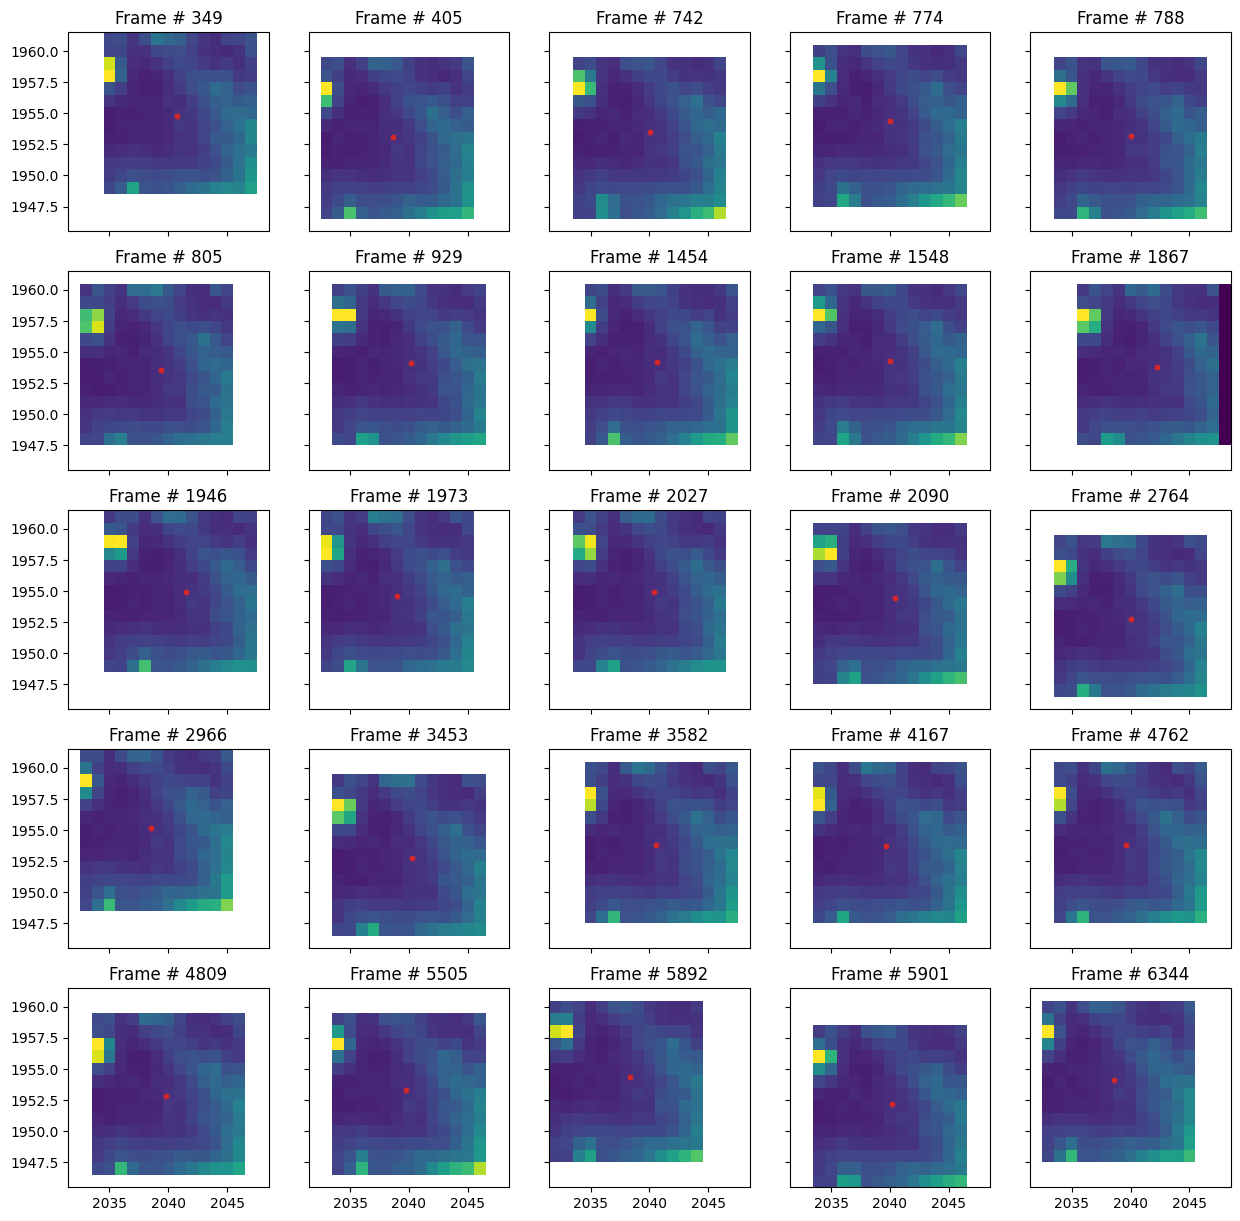

In [23]:
Ts = np.sort(np.random.choice(np.arange(rcube.nt), size=5*5, replace=False))

fig, ax = plt.subplots(5,5,figsize=(15,15),sharex=True, sharey=True)
for t, axis in zip(Ts, ax.ravel()):
    axis.pcolormesh(rcube.column[t], rcube.row[t], rcube.flux[t], vmin=-10, vmax=500, cmap="viridis")
    axis.scatter(rcube.target_pixel[t, 1],rcube.target_pixel[t, 0], c="tab:red", s=10)
    axis.set_title(f"Frame # {t}")
plt.show()

In [24]:
sizeof_fmt(sys.getsizeof(rcube.flux)), sizeof_fmt(sys.getsizeof(rcube.flux_err)), sizeof_fmt(sys.getsizeof(rcube.time))

('8.5MiB', '8.5MiB', '51.6KiB')

In [25]:
rcube.make_cutout(rowcol=(1954, 2030), size=(21, 21), dithered=False)

Getting 3d data...


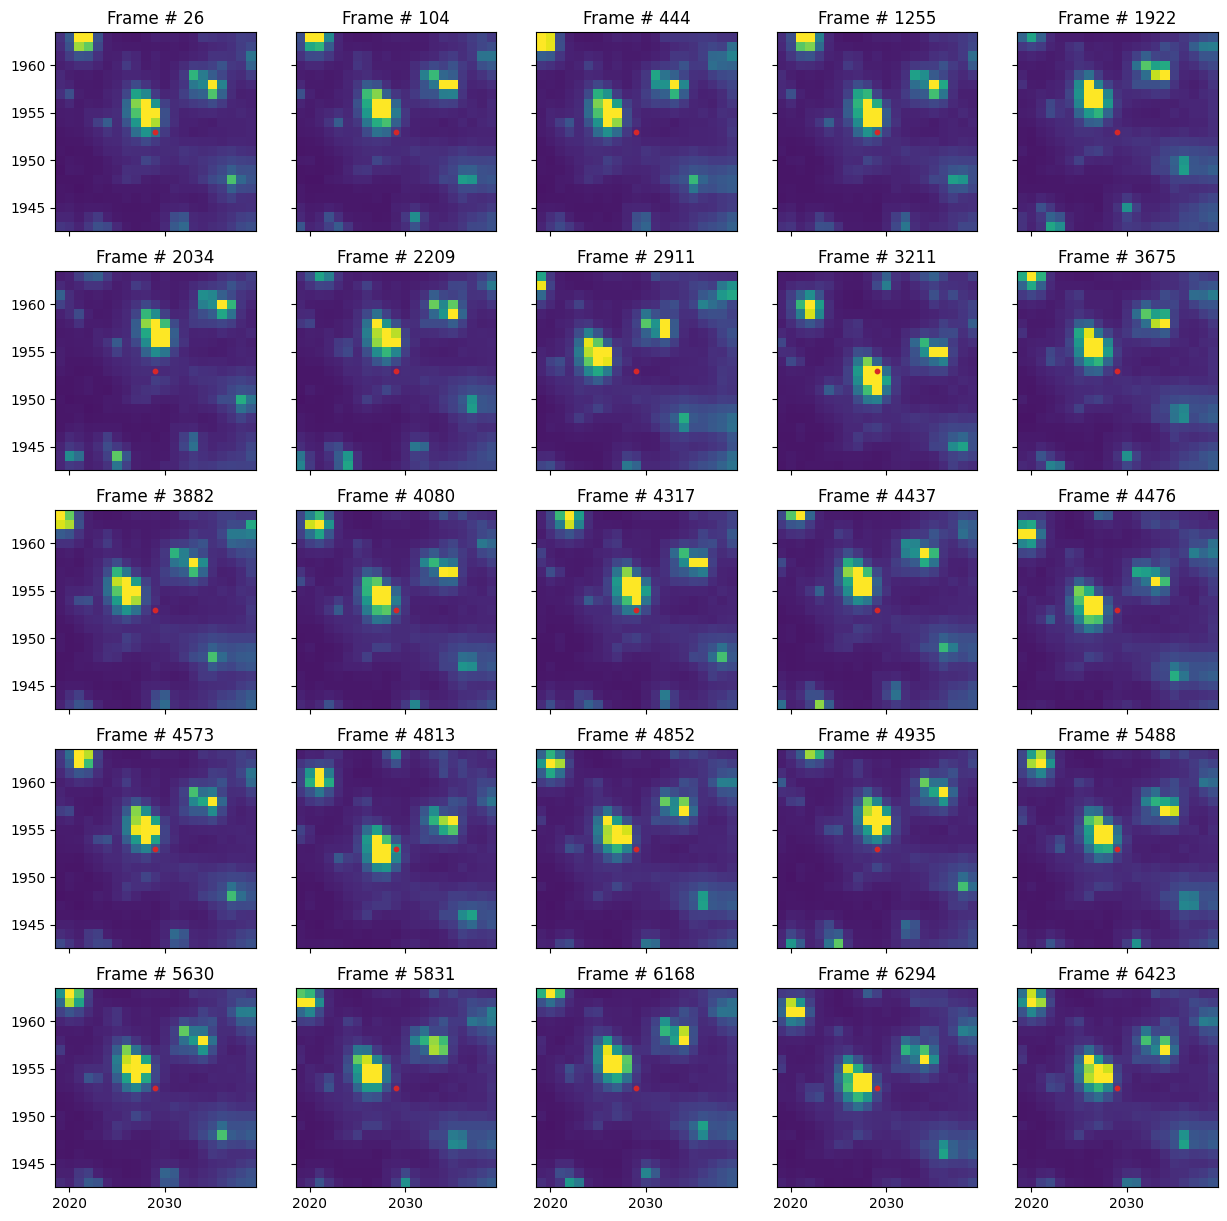

In [26]:
Ts = np.sort(np.random.choice(np.arange(rcube.nt), size=5*5, replace=False))

fig, ax = plt.subplots(5,5,figsize=(15,15),sharex=True, sharey=True)
for t, axis in zip(Ts, ax.ravel()):
    axis.pcolormesh(rcube.column, rcube.row, rcube.flux[t], vmin=-10, vmax=500, cmap="viridis")
    axis.scatter(rcube.target_pixel[1],rcube.target_pixel[0], c="tab:red", s=10)
    axis.set_title(f"Frame # {t}")
plt.show()